# Entraînement — Conditional WGAN-GP

Entraîne un GAN conditionnel (Wasserstein + gradient penalty) sur les cartes SWI.
Le générateur produit des cartes conditionnées sur le mois (encodage sinusoïdal).

**Choix architectural :**
- **WGAN-GP** : loss de Wasserstein + pénalité de gradient → training stable, pas de mode collapse
- Même conditionnement que le CVAE : `[sin(2π·m/12), cos(2π·m/12)]`
- Critique sans normalisation par batch (exigence WGAN-GP)

> **Pré-requis** : avoir exécuté `preprocessing_cartes.ipynb`.

## 1. Imports et setup

In [1]:
import sys, torch, torch.nn as nn, numpy as np, json, gc
import pandas as pd, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

ROOT_DIR   = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
MAPS_DIR   = ROOT_DIR / 'data' / 'maps'
MODELS_DIR = ROOT_DIR / 'training_notebook' / 'models'
MODELS_DIR.mkdir(exist_ok=True, parents=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sys.path.insert(0, str(ROOT_DIR))
from models_archi import COND_DIM, SWIMapDataset, Generator, Critic, CGAN

print(f'Device : {device}')

Device : cpu


## 2. Configuration

In [2]:
# ── Hyperparamètres ────────────────────────────────────────────
LATENT_DIM = 10    # dimension de l'espace latent
BATCH_SIZE = 16
N_EPOCHS   = 150
LR         = 1e-4
N_CRITIC   = 5     # steps critique par step générateur
LAMBDA_GP  = 10    # poids de la gradient penalty
PATIENCE   = 20    # early stopping (après warmup)
WARMUP     = 30    # epochs avant d'activer l'early stopping
# ──────────────────────────────────────────────────────────────

print(f'LATENT_DIM={LATENT_DIM}  N_CRITIC={N_CRITIC}  LAMBDA_GP={LAMBDA_GP}')

LATENT_DIM=10  N_CRITIC=5  LAMBDA_GP=10


## 3. Chargement des données

In [3]:
with open(MAPS_DIR / 'metadata.json') as f:
    meta = json.load(f)

H, W         = meta['H'], meta['W']
H_pad, W_pad = meta['H_pad'], meta['W_pad']
months_arr   = np.array(meta['months'], dtype=np.int32)
years_arr    = np.array(meta['years'],  dtype=np.int32)
monthly_stats = {int(k): tuple(v) for k, v in meta['monthly_stats'].items()}

swi_padded = np.load(MAPS_DIR / 'swi_padded.npy')
land_mask  = np.load(MAPS_DIR / 'land_mask.npy')
mask_padded = np.load(MAPS_DIR / 'mask_padded.npy')

mask_train = years_arr < 2018
mask_test  = years_arr >= 2018

train_loader = DataLoader(
    SWIMapDataset(swi_padded[mask_train], months_arr[mask_train]),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader = DataLoader(
    SWIMapDataset(swi_padded[mask_test],  months_arr[mask_test]),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Données : {swi_padded.shape}  Train {mask_train.sum()} | Test {mask_test.sum()}')

Données : (780, 136, 136)  Train 696 | Test 84


## 4. Modèle et optimiseurs

In [4]:
G = Generator(H_pad, W_pad, ldim=LATENT_DIM).to(device)
D = Critic(H_pad, W_pad).to(device)

# Adam avec β1=0 (recommandé WGAN-GP)
opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.0, 0.9))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.0, 0.9))

n_G = sum(p.numel() for p in G.parameters() if p.requires_grad)
n_D = sum(p.numel() for p in D.parameters() if p.requires_grad)
print(f'Générateur : {n_G:,} params')
print(f'Critique   : {n_D:,} params')

Générateur : 19,148,193 params
Critique   : 202,593 params


## 5. Entraînement WGAN-GP

In [6]:
from tqdm.auto import tqdm

def gradient_penalty(critic, real, fake, cond):
    """Pénalité de gradient WGAN-GP sur des interpolations real/fake."""
    B = real.size(0)
    alpha  = torch.rand(B, 1, 1, 1, device=real.device)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    score  = critic(interp, cond)
    grad   = torch.autograd.grad(
        outputs=score, inputs=interp,
        grad_outputs=torch.ones_like(score),
        create_graph=True, retain_graph=True)[0]
    return ((grad.flatten(1).norm(2, dim=1) - 1) ** 2).mean()


history = {"loss_G": [], "loss_D": [], "wasserstein": []}
best_G, no_improve = float("inf"), 0
best_state_G = best_state_D = None

epoch_bar = tqdm(range(1, N_EPOCHS + 1), desc="Entraînement", unit="ep")

for ep in epoch_bar:
    G.train(); D.train()
    sum_G = sum_D = sum_W = 0

    batch_bar = tqdm(train_loader, desc=f"  Ep {ep:3d}", leave=False,
                     unit="batch", dynamic_ncols=True)
    for x, c, _ in batch_bar:
        x, c = x.to(device), c.to(device)
        B = x.size(0)

        # ── Critique N_CRITIC fois ───────────────────────
        for _ in range(N_CRITIC):
            z      = torch.randn(B, LATENT_DIM, device=device)
            fake   = G(z, c).detach()
            gp     = gradient_penalty(D, x, fake, c)
            w_dist = D(x, c).mean() - D(fake, c).mean()
            loss_D = -w_dist + LAMBDA_GP * gp
            opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # ── Générateur (1 fois) ──────────────────────────
        z      = torch.randn(B, LATENT_DIM, device=device)
        fake   = G(z, c)
        loss_G = -D(fake, c).mean()
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        sum_G += loss_G.item()
        sum_D += loss_D.item()
        sum_W += w_dist.item()
        batch_bar.set_postfix(G=f"{loss_G.item():.3f}",
                              D=f"{loss_D.item():.3f}",
                              W=f"{w_dist.item():.3f}")

    n = len(train_loader)
    avg_G, avg_D, avg_W = sum_G / n, sum_D / n, sum_W / n
    history["loss_G"].append(avg_G)
    history["loss_D"].append(avg_D)
    history["wasserstein"].append(avg_W)

    epoch_bar.set_postfix(
        loss_G=f"{avg_G:.4f}",
        loss_D=f"{avg_D:.4f}",
        W_dist=f"{avg_W:.4f}",
        best=f"{best_G:.4f}" if best_G < float("inf") else "-"
    )

    # Early stopping sur loss_G après le warmup
    if ep > WARMUP:
        if avg_G < best_G - 1e-3:
            best_G, no_improve = avg_G, 0
            best_state_G = {k: v.cpu().clone() for k, v in G.state_dict().items()}
            best_state_D = {k: v.cpu().clone() for k, v in D.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                epoch_bar.set_description(f"Early stop (ep {ep})")
                break

if best_state_G:
    G.load_state_dict(best_state_G)
    D.load_state_dict(best_state_D)
print(f"Terminé — meilleure loss_G : {best_G:.4f}")


Entraînement:   0%|          | 0/150 [00:00<?, ?ep/s]

Early stop (ep 51):  33%|███▎      | 50/150 [39:31<1:19:02, 47.42s/ep, W_dist=22.5054, best=-102.9675, loss_D=-19.2000, loss_G=-78.0370]

Terminé — meilleure loss_G : -102.9675


## 6. Sauvegarde

In [7]:
torch.save(G.state_dict(), MODELS_DIR / 'cgan_generator.pth')
torch.save(D.state_dict(), MODELS_DIR / 'cgan_critic.pth')
torch.save(history,        MODELS_DIR / 'cgan_history.pt')

with open(MODELS_DIR / 'cgan_config.json', 'w') as f:
    json.dump({'LATENT_DIM': LATENT_DIM}, f)

print(f'Modèles sauvegardés dans {MODELS_DIR}  (LATENT_DIM={LATENT_DIM})')

Modèles sauvegardés dans c:\Users\thoma\OneDrive\Bureau\boulot\gen_ai_assu\generative-ai-actuarial-studies\training_notebook\models  (LATENT_DIM=10)


## 7. Courbes d'entraînement

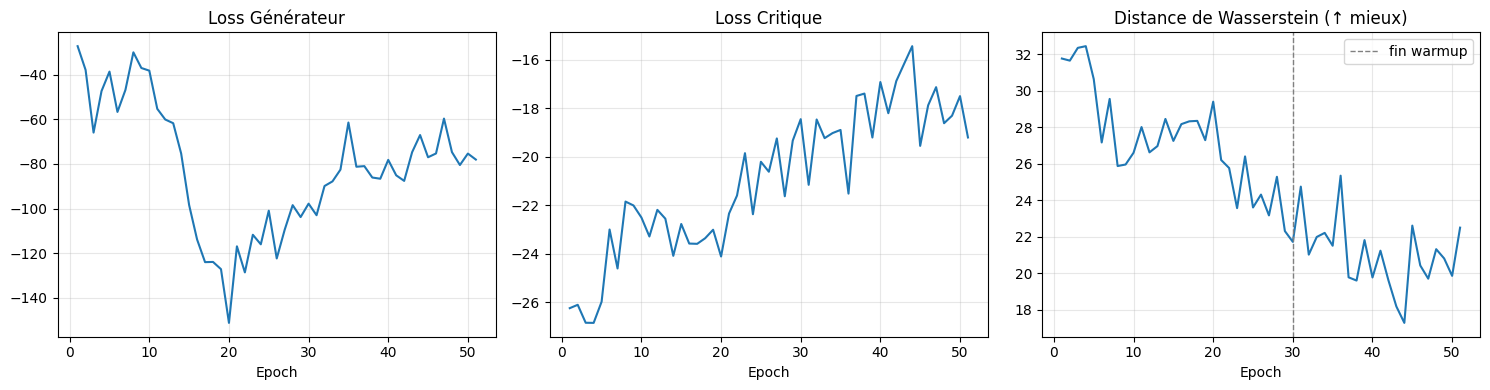

In [8]:
eps = range(1, len(history['loss_G']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(eps, history['loss_G'])
axes[0].set_title('Loss Générateur'); axes[0].set_xlabel('Epoch')

axes[1].plot(eps, history['loss_D'])
axes[1].set_title('Loss Critique'); axes[1].set_xlabel('Epoch')

axes[2].plot(eps, history['wasserstein'])
axes[2].set_title('Distance de Wasserstein (↑ mieux)'); axes[2].set_xlabel('Epoch')
axes[2].axvline(WARMUP, ls='--', c='gray', lw=1, label='fin warmup')
axes[2].legend()

for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Aperçu — cartes générées

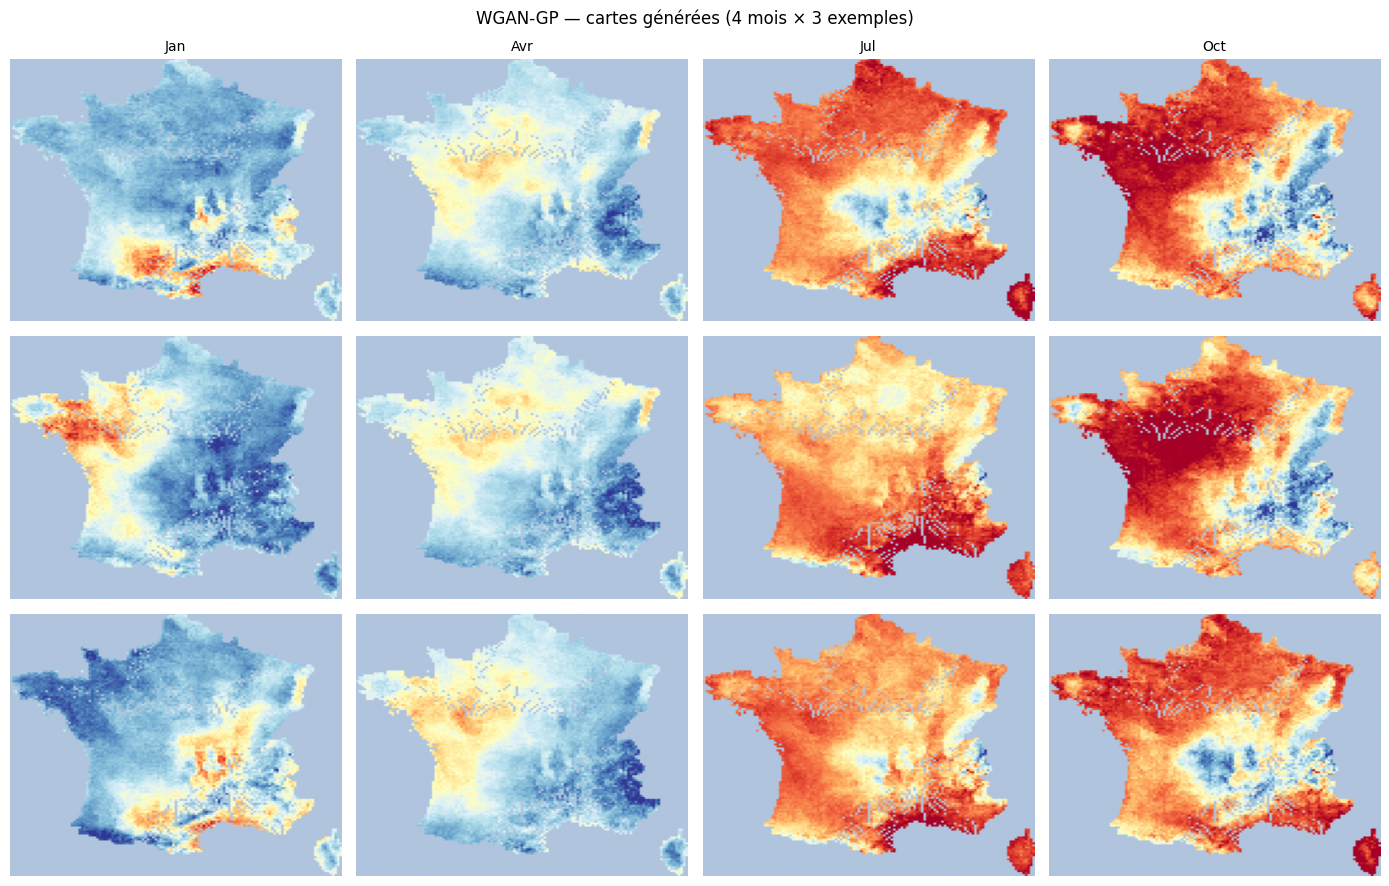

In [11]:
G.eval()
cmap_swi = plt.cm.RdYlBu.copy()
cmap_swi.set_bad(color='#b0c4de')

m_lbl = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']

@torch.no_grad()
def generate_maps(model, month, n=4):
    theta = 2 * np.pi * month / 12
    cond  = torch.tensor([[np.sin(theta), np.cos(theta)]] * n,
                         dtype=torch.float32, device=device)
    z     = torch.randn(n, LATENT_DIM, device=device)
    out   = model(z, cond).cpu().numpy()   # (n, 1, H_pad, W_pad)
    mu_m, sig_m = monthly_stats[month]
    maps  = out[:, 0, :H, :W] * sig_m + mu_m
    maps[:, ~land_mask] = np.nan
    return maps

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle('WGAN-GP — cartes générées (4 mois × 3 exemples)', fontsize=12)
for col, month in enumerate([1, 4, 7, 10]):
    maps = generate_maps(G, month, n=3)
    for row in range(3):
        axes[row, col].imshow(maps[row], cmap=cmap_swi, origin='lower',
                              vmin=0, vmax=1.3, aspect='auto')
        axes[row, col].axis('off')
    axes[0, col].set_title(m_lbl[month - 1], fontsize=10)
plt.tight_layout(); plt.show()